# import all necessary packages

In [2140]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor,StackingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,root_mean_squared_error
import pickle

# understanding the data

In [2141]:
df=pd.read_csv('raw_data.csv')

In [2142]:
df.sample(5)

,model,price,rating,os,sim_type,network_type,VoLTE,NFC,ir_blaster,chipset,...,resolution,refresh_rate_hz,display_type,rear_camera_mp_list,rear_camera_count,rear_camera_max_mp,front_camera_mp,memory_card_supported,memory_card_type,memory_card_max_gb
932,oppo a53 2020,13990,70.0,Android v10,Dual,4g,True,False,False,Snapdragon 460,...,1600x720,90.0,Punch Hole,"[13, 2, 2]",3,13.0,16.0,1,Dedicated,256.0
899,samsung galaxy m35,22999,74.0,Android v12,Dual,4g,True,True,False,Octa Core Processor,...,1080x2400,NaN,Water Drop Notch,"[64, 8, 5]",3,64.0,32.0,1,Dedicated,1024.0
398,realme gt neo 5,34999,83.0,Android v13,Dual,5g,True,True,False,Snapdragon 8+ Gen1,...,1080x2412,120.0,Punch Hole,"[50, 8, 2]",3,50.0,16.0,1,Dedicated,NaN
428,vertu signature touch,650000,62.0,Android v4.4.2 (KitKat),Single,4g,False,True,False,Snapdragon 801,...,1080x1920,NaN,NaN,[13],1,13.0,NaN,1,NaN,NaN
374,realme 11 pro plus,24999,78.0,Android v12,Dual,5g,True,False,False,Dimensity 930,...,1080x2400,90.0,Punch Hole,"[50, 8, 2]",3,50.0,16.0,1,NaN,NaN


In [2143]:
df['core_type'].value_counts()

core_type
Octa Core    888
Hexa Core     39
Quad Core     34
Dual Core      1
Name: count, dtype: int64

In [2144]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 968 entries, 0 to 967
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   model                  968 non-null    object 
 1   price                  968 non-null    int64  
 2   rating                 968 non-null    float64
 3   os                     942 non-null    object 
 4   sim_type               968 non-null    object 
 5   network_type           968 non-null    object 
 6   VoLTE                  968 non-null    bool   
 7   NFC                    968 non-null    bool   
 8   ir_blaster             968 non-null    bool   
 9   chipset                968 non-null    object 
 10  core_type              962 non-null    object 
 11  clock_ghz              927 non-null    float64
 12  ram_gb                 968 non-null    int64  
 13  storage_gb             968 non-null    int64  
 14  battery_mah            957 non-null    float64
 15  fast_c

In [2145]:
df.describe()

,price,rating,clock_ghz,ram_gb,storage_gb,battery_mah,fast_charge_w,screen_size_in,refresh_rate_hz,rear_camera_count,rear_camera_max_mp,front_camera_mp,memory_card_supported,memory_card_max_gb
count,968.000000,968.000000,927.000000,968.000000,968.000000,957.000000,764.00000,967.000000,608.000000,968.000000,952.000000,943.000000,968.0,500.000000
mean,32745.954545,78.540289,2.430237,7.641529,7.641529,4819.935214,46.25877,6.535998,111.656250,2.268595,50.737395,16.714740,1.0,741.136000
std,39707.710721,6.953266,0.464864,23.123619,23.123619,1012.724563,34.30833,0.381498,18.488393,0.905096,33.209502,10.889245,0.0,375.426488
min,2999.000000,60.000000,1.000000,1.000000,1.000000,1500.000000,10.00000,2.400000,90.000000,0.000000,2.000000,2.000000,1.0,32.000000
25%,12999.000000,75.000000,2.050000,4.000000,4.000000,4500.000000,18.00000,6.500000,90.000000,1.000000,48.000000,8.000000,1.0,512.000000
50%,19999.000000,80.000000,2.360000,6.000000,6.000000,5000.000000,33.00000,6.580000,120.000000,3.000000,50.000000,16.000000,1.0,1024.000000
75%,35992.250000,84.000000,2.840000,8.000000,8.000000,5000.000000,66.00000,6.670000,120.000000,3.000000,64.000000,16.000000,1.0,1024.000000
max,650000.000000,89.000000,3.220000,512.000000,512.000000,22000.000000,240.00000,8.030000,240.000000,4.000000,200.000000,60.000000,1.0,2048.000000


In [2146]:
df.shape

(968, 27)

In [2147]:
df = df[df["price"] <= 150000]

In [2148]:
df.shape

(955, 27)

In [2149]:
df.columns

Index(['model', 'price', 'rating', 'os', 'sim_type', 'network_type', 'VoLTE',
       'NFC', 'ir_blaster', 'chipset', 'core_type', 'clock_ghz', 'ram_gb',
       'storage_gb', 'battery_mah', 'fast_charge_w', 'screen_size_in',
       'resolution', 'refresh_rate_hz', 'display_type', 'rear_camera_mp_list',
       'rear_camera_count', 'rear_camera_max_mp', 'front_camera_mp',
       'memory_card_supported', 'memory_card_type', 'memory_card_max_gb'],
      dtype='object')

### feature transformation
- introducing a new column name company name as there were too many model name

In [2150]:
df['company_name']=df['model'].apply(lambda x:x.split()[0])

In [2151]:
df['company_name'].unique()

array(['oneplus', 'samsung', 'motorola', 'realme', 'apple', 'xiaomi',
       'nothing', 'oppo', 'vivo', 'poco', 'iqoo', 'jio', 'gionee',
       'tecno', 'tesla', 'google', 'infinix', 'cola', 'letv', 'ikall',
       'leeco', 'duoqin', 'nokia', 'lava', 'honor', 'nubia', 'redmi',
       'asus', 'itel', 'royole', 'sony', 'oukitel', 'blu', 'huawei',
       'zte', 'lenovo', 'lg', 'micromax', 'leitz', 'cat', 'doogee', 'tcl',
       'sharp', 'blackview'], dtype=object)

In [2152]:
counts = df['company_name'].value_counts()

df['company_name'] = df['company_name'].apply(
    lambda x: x if counts[x] >= 10 else 'other'
)

<Axes: xlabel='count', ylabel='company_name'>

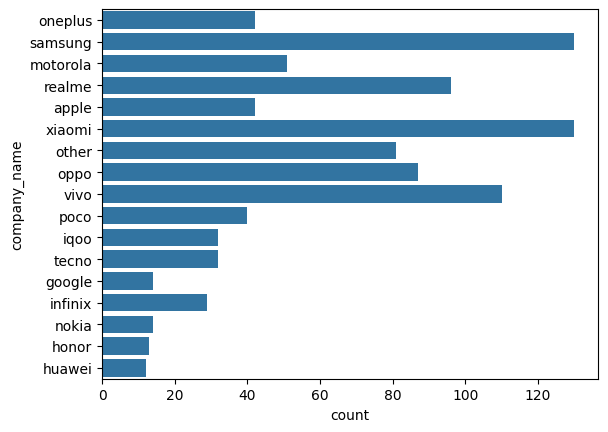

In [2153]:
sns.countplot(df['company_name'])

In [2154]:
# ranging the rating from 0 to 10
df['rating']=df['rating'].apply(lambda x:x/10)

## checking missing value 

In [2155]:
df.isnull().sum()

model                      0
price                      0
rating                     0
os                        22
sim_type                   0
network_type               0
VoLTE                      0
NFC                        0
ir_blaster                 0
chipset                    0
core_type                  6
clock_ghz                 38
ram_gb                     0
storage_gb                 0
battery_mah               11
fast_charge_w            198
screen_size_in             1
resolution                 1
refresh_rate_hz          355
display_type              77
rear_camera_mp_list        0
rear_camera_count          0
rear_camera_max_mp        14
front_camera_mp           21
memory_card_supported      0
memory_card_type         120
memory_card_max_gb       459
company_name               0
dtype: int64

In [2156]:
df.select_dtypes(exclude='object').corr()

,price,rating,VoLTE,NFC,ir_blaster,clock_ghz,ram_gb,storage_gb,battery_mah,fast_charge_w,screen_size_in,refresh_rate_hz,rear_camera_count,rear_camera_max_mp,front_camera_mp,memory_card_supported,memory_card_max_gb
price,1.000000,0.410572,0.051466,0.591220,-0.049092,0.699013,0.021513,0.021513,-0.135049,0.386857,0.196269,0.427885,0.098089,0.159041,0.282350,NaN,0.196062
rating,0.410572,1.000000,0.006891,0.453049,0.141916,0.539424,0.086215,0.086215,-0.036465,0.494957,0.145024,0.476594,0.269781,0.471857,0.526288,NaN,0.295096
VoLTE,0.051466,0.006891,1.000000,0.027589,0.040301,0.139910,-0.238495,-0.238495,0.090306,-0.029495,0.267334,-0.026330,0.091450,0.065263,-0.024066,NaN,0.094087
NFC,0.591220,0.453049,0.027589,1.000000,-0.041414,0.608510,0.016935,0.016935,-0.100022,0.385672,0.096186,0.396859,0.175034,0.130678,0.297103,NaN,0.227061
ir_blaster,-0.049092,0.141916,0.040301,-0.041414,1.000000,0.096021,-0.014573,-0.014573,0.058446,0.186263,0.121159,0.020335,0.030828,0.241416,0.005566,NaN,-0.054417
clock_ghz,0.699013,0.539424,0.139910,0.608510,0.096021,1.000000,-0.067805,-0.067805,-0.039841,0.621027,0.282000,0.513036,0.258113,0.275062,0.398690,NaN,0.288467
ram_gb,0.021513,0.086215,-0.238495,0.016935,-0.014573,-0.067805,1.000000,1.000000,-0.130624,0.539648,-0.448858,0.423093,-0.062899,0.021095,0.534523,NaN,-0.046142
storage_gb,0.021513,0.086215,-0.238495,0.016935,-0.014573,-0.067805,1.000000,1.000000,-0.130624,0.539648,-0.448858,0.423093,-0.062899,0.021095,0.534523,NaN,-0.046142
battery_mah,-0.135049,-0.036465,0.090306,-0.100022,0.058446,-0.039841,-0.130624,-0.130624,1.000000,-0.080469,0.360174,0.023034,0.048457,0.158722,-0.018020,NaN,0.233881
fast_charge_w,0.386857,0.494957,-0.029495,0.385672,0.186263,0.621027,0.539648,0.539648,-0.080469,1.000000,0.285343,0.466137,0.267152,0.386921,0.390461,NaN,0.032710


- droping the columns which have low corellation,too many missing values ,unwanted

In [2157]:
df=df.drop(['memory_card_supported', 'memory_card_type', 
            'memory_card_max_gb','refresh_rate_hz','fast_charge_w',
            'rear_camera_mp_list','rear_camera_count','model','ir_blaster','VoLTE'],axis=1)

In [2158]:
df.columns

Index(['price', 'rating', 'os', 'sim_type', 'network_type', 'NFC', 'chipset',
       'core_type', 'clock_ghz', 'ram_gb', 'storage_gb', 'battery_mah',
       'screen_size_in', 'resolution', 'display_type', 'rear_camera_max_mp',
       'front_camera_mp', 'company_name'],
      dtype='object')

In [2159]:
df.isnull().sum()

price                  0
rating                 0
os                    22
sim_type               0
network_type           0
NFC                    0
chipset                0
core_type              6
clock_ghz             38
ram_gb                 0
storage_gb             0
battery_mah           11
screen_size_in         1
resolution             1
display_type          77
rear_camera_max_mp    14
front_camera_mp       21
company_name           0
dtype: int64

- as the data is categorical and we just cannot fill most occuring value in missing data so we are dropping the missing value row

In [2160]:
df=df.dropna()

In [2161]:
df.select_dtypes(exclude='object').corr()

,price,rating,NFC,clock_ghz,ram_gb,storage_gb,battery_mah,screen_size_in,rear_camera_max_mp,front_camera_mp
price,1.000000,0.501809,0.611871,0.715150,0.563223,0.563223,-0.164708,0.107121,0.238930,0.365734
rating,0.501809,1.000000,0.503052,0.583458,0.705623,0.705623,-0.065316,0.201334,0.507983,0.560453
NFC,0.611871,0.503052,1.000000,0.583807,0.452232,0.452232,-0.114958,0.103173,0.189878,0.339093
clock_ghz,0.715150,0.583458,0.583807,1.000000,0.609179,0.609179,-0.140953,0.166722,0.295715,0.415467
ram_gb,0.563223,0.705623,0.452232,0.609179,1.000000,1.000000,-0.015840,0.285185,0.445162,0.567055
storage_gb,0.563223,0.705623,0.452232,0.609179,1.000000,1.000000,-0.015840,0.285185,0.445162,0.567055
battery_mah,-0.164708,-0.065316,-0.114958,-0.140953,-0.015840,-0.015840,1.000000,0.265532,0.095770,-0.072914
screen_size_in,0.107121,0.201334,0.103173,0.166722,0.285185,0.285185,0.265532,1.000000,0.324556,0.154219
rear_camera_max_mp,0.238930,0.507983,0.189878,0.295715,0.445162,0.445162,0.095770,0.324556,1.000000,0.450313
front_camera_mp,0.365734,0.560453,0.339093,0.415467,0.567055,0.567055,-0.072914,0.154219,0.450313,1.000000


In [2162]:
df.shape

(826, 18)

In [2163]:
df['os'].value_counts()

os
Android v12            350
Android v11            259
Android v13             72
Android v10             58
Android v9.0 (Pie)      24
Android v10.0           22
iOS v16                  6
iOS v15                  6
Android v8.1 (Oreo)      6
Android v11.0            4
iOS v15.0                3
iOS v13                  3
Harmony v2.0             2
Android v12.1            2
HarmonyOS v2.0           2
HarmonyOS v2             1
iOS v13.0                1
Hongmeng OS v4.0         1
Android v8.0 (Oreo)      1
HarmonyOS                1
EMUI v12                 1
Android v9 (Pie)         1
Name: count, dtype: int64

- as there are many os type some of them are very low version so we will keep only modern versions and keep the rest in other

In [2164]:
df['os'] = df['os'].apply(lambda x: 'Andriod' if 'Android' in x else ('IOS' if 'iOS' in x else 'Other'))


In [2165]:
df['os'].value_counts()

os
Andriod    799
IOS         19
Other        8
Name: count, dtype: int64

- in the chipset there are too many unique values so we will clean and group them

In [2166]:
df['chipset'].value_counts()

chipset
Dimensity 700 5G    28
Helio P35           28
Snapdragon 680      23
Snapdragon 695      22
Helio G35           20
                    ..
Dimensity 1000+      1
Helio  G90T          1
Unisoc  A55          1
Snapdragon 450       1
Snapdragon 710       1
Name: count, Length: 196, dtype: int64

In [ ]:
counts = df['chipset'].value_counts()

df['chipset'] = df['chipset'].apply(lambda x: x if counts[x] >=10 else 'Other')

In [2168]:
df['chipset'] = df['chipset'].apply(lambda x: x.split()[0])

In [2169]:
df['chipset'].value_counts()

chipset
Other         444
Snapdragon    171
Helio         119
Dimensity      77
Bionic         15
Name: count, dtype: int64

- renaming camera columns and changing there dtype

In [2170]:
df=df.rename(columns={'rear_camera_max_mp': 'rear_camera',
                   'front_camera_mp':'front_camera'})

In [2171]:
df['rear_camera']=df['rear_camera'].astype(int)
df['front_camera']=df['front_camera'].astype(int)

In [2172]:
df['resx'] = df['resolution'].apply(lambda x: x.split('x')[0])

In [2173]:
df['resy'] = df['resolution'].apply(lambda x: x.split('x')[1])

In [2174]:
df=df.drop('resolution',axis=1)

In [2175]:
df['resx']=df['resx'].astype(int)
df['resy']=df['resy'].astype(int)

In [2176]:
df['storage_gb'].value_counts()

storage_gb
8     294
6     206
4     191
12     59
3      44
2      24
16      5
1       3
Name: count, dtype: int64

In [2177]:
df.sample(6)

,price,rating,os,sim_type,network_type,NFC,chipset,core_type,clock_ghz,ram_gb,storage_gb,battery_mah,screen_size_in,display_type,rear_camera,front_camera,company_name,resx,resy
889,8390,6.3,Andriod,Dual,4g,False,Helio,Octa Core,2.3,3,3,5000.0,6.60,Water Drop Notch,13,8,tecno,720,1600
493,17990,7.6,Andriod,Dual,5g,False,Other,Octa Core,2.2,6,6,4500.0,6.64,Punch Hole,50,8,vivo,1080,2388
717,44990,8.7,Andriod,Dual,5g,True,Snapdragon,Octa Core,3.2,8,8,4500.0,6.55,Punch Hole,50,32,oppo,1080,2400
543,14999,7.4,Andriod,Dual,5g,False,Snapdragon,Octa Core,2.2,4,4,5000.0,6.67,Punch Hole,48,8,poco,1080,2400
353,7145,8.0,Andriod,Dual,4g,False,Other,Octa Core,1.6,2,2,5000.0,6.50,Water Drop Notch,8,5,realme,720,1600
74,13999,7.9,Andriod,Dual,5g,False,Other,Octa Core,2.2,6,6,5000.0,6.50,Punch Hole,48,8,xiaomi,1080,2400


In [2178]:
df['os'].value_counts()

os
Andriod    799
IOS         19
Other        8
Name: count, dtype: int64

- doing feature engineering

In [2179]:
# ppi = pixel per inch
df["ppi"] = ((df["resx"]**2 + df["resy"]**2)**0.5) / df["screen_size_in"]
# performance score estimates how powerful a phone is
df["performance_score"] = df["ram_gb"] * df["clock_ghz"]

In [2180]:
df.select_dtypes(exclude='object').corr()

,price,rating,NFC,clock_ghz,ram_gb,storage_gb,battery_mah,screen_size_in,rear_camera,front_camera,resx,resy,ppi,performance_score
price,1.000000,0.501809,0.611871,0.715150,0.563223,0.563223,-0.164708,0.107121,0.238930,0.365734,0.356985,0.559803,0.606777,0.670085
rating,0.501809,1.000000,0.503052,0.583458,0.705623,0.705623,-0.065316,0.201334,0.507983,0.560453,0.435249,0.629789,0.695302,0.696253
NFC,0.611871,0.503052,1.000000,0.583807,0.452232,0.452232,-0.114958,0.103173,0.189878,0.339093,0.307982,0.413655,0.465469,0.542737
clock_ghz,0.715150,0.583458,0.583807,1.000000,0.609179,0.609179,-0.140953,0.166722,0.295715,0.415467,0.311630,0.546940,0.571149,0.791826
ram_gb,0.563223,0.705623,0.452232,0.609179,1.000000,1.000000,-0.015840,0.285185,0.445162,0.567055,0.333208,0.589853,0.599553,0.954604
storage_gb,0.563223,0.705623,0.452232,0.609179,1.000000,1.000000,-0.015840,0.285185,0.445162,0.567055,0.333208,0.589853,0.599553,0.954604
battery_mah,-0.164708,-0.065316,-0.114958,-0.140953,-0.015840,-0.015840,1.000000,0.265532,0.095770,-0.072914,-0.047330,-0.042558,-0.094247,-0.058682
screen_size_in,0.107121,0.201334,0.103173,0.166722,0.285185,0.285185,0.265532,1.000000,0.324556,0.154219,0.185698,0.260023,0.157233,0.285880
rear_camera,0.238930,0.507983,0.189878,0.295715,0.445162,0.445162,0.095770,0.324556,1.000000,0.450313,0.276704,0.412463,0.423160,0.410939
front_camera,0.365734,0.560453,0.339093,0.415467,0.567055,0.567055,-0.072914,0.154219,0.450313,1.000000,0.272345,0.447710,0.473910,0.552152


- splitting data in testing and training

In [2181]:
X=df.drop(['price', 'front_camera','resx', 'resy','clock_ghz', 'ram_gb'
           ,'sim_type','screen_size_in','storage_gb'],axis=1)
y=df['price']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [2182]:
X_train.columns

Index(['rating', 'os', 'network_type', 'NFC', 'chipset', 'core_type',
       'battery_mah', 'display_type', 'rear_camera', 'company_name', 'ppi',
       'performance_score'],
      dtype='object')

In [2183]:
num_cols=X_train.select_dtypes(exclude='object').columns
cat_cols=X_train.select_dtypes(include='object').columns

In [2184]:
estimators = [
    ("rf", RandomForestRegressor(
        n_estimators=300,
        random_state=42
    )),
    
    ("xgb", XGBRegressor(
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=7,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )),
    
    ("lgbm", LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.03,
        random_state=42
    ))
]
final_estimator = Ridge()

In [2185]:
stack_model = StackingRegressor(
    estimators=estimators,
    final_estimator=final_estimator,
    passthrough=False,
    n_jobs=-1
)

In [2186]:
preprocessor=ColumnTransformer([
    ('scaling',StandardScaler(),num_cols),
    ('encoder',OneHotEncoder(drop='first'),cat_cols)
])
model=Pipeline([
    ('preprocessing',preprocessor),
    ('linear_model',stack_model)
])

In [2187]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [2188]:
model.fit(X_train, y_train_log)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('linear_model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaling', ...), ('encoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different

In [2189]:
pred_log = model.predict(X_test)

# Convert back to actual prices
pred_actual = np.expm1(pred_log)
y_test_actual = np.expm1(y_test_log)

# Metrics
mae = mean_absolute_error(y_test_actual, pred_actual)
r2 = r2_score(y_test_actual, pred_actual)

print("MAE:", mae)
print("R2:", r2)

MAE: 4455.0836508738485
R2: 0.842778382900087


c:\Users\shiva\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [2190]:
r2_log = r2_score(y_test_log, pred_log)
print("R2 (log scale):", r2_log)

R2 (log scale): 0.8957913654507398


In [2191]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, np.log1p(y), cv=5, scoring='r2')
print(scores.mean())

c:\Users\shiva\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\shiva\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\shiva\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\shiva\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


0.910463019091222


c:\Users\shiva\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [2192]:
df.to_csv('mobile_data.csv',index=False)

In [2193]:
with open('mobile_model.pkl' ,'wb') as file:
    pickle.dump(model,file)